# 06 — Results Analysis  *(corrected — honest CI framing + country audit)*

**Corrections:** CI language now explicitly notes single-fold limitation. Country-level error audit added.


## Cell 1 — Imports and Load

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.utils import resample
import shap, xgboost as xgb, tempfile, os

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
IMP_DIR = BASE/'data'/'processed'/'sentiment_improved'
AUG_DIR = BASE/'data'/'processed'/'augmented_lags'
FIG_DIR = BASE/'figures'/'sentiment_improved'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df_model    = pd.read_csv(IMP_DIR/'df_model_imp.csv')
results_df  = pd.read_csv(IMP_DIR/'model_results.csv')
shap_df     = pd.read_csv(IMP_DIR/'shap_values_m3.csv')
oos_df      = pd.read_csv(IMP_DIR/'oos_predictions.csv')
M3_FEATURES = pd.read_csv(IMP_DIR/'M3_features.csv',header=None)[0].tolist()
M1_FEATURES = pd.read_csv(IMP_DIR/'M1_features.csv',header=None)[0].tolist()

# Detect target column robustly
TARGET = next((c for c in oos_df.columns if 'target' in c.lower()), None)
if TARGET is None:
    TARGET = next(c for c in oos_df.columns if 'crisis' in c.lower()
                  and c not in ['crisisjst','crisisjst_old'])
y_true = oos_df[TARGET].values

print(f'Target         : {TARGET}')
print(f'OOS events     : {int(y_true.sum())}')
print(f'df_model shape : {df_model.shape}')
print(f'SHAP shape     : {shap_df.shape}')
print()
print(results_df.to_string(index=False))

Target         : target_h2
OOS events     : 26
df_model shape : (319, 203)
SHAP shape     : (319, 61)

                       Model    AUROC    AUPRC    Brier
      M1_Logistic_macro_lag1 0.876114 0.285044 0.211810
M2_RandomForest_macro_lag123 0.946524 0.560704 0.050576
     M3_XGBoost_sent_rolling 0.958556 0.656877 0.082625


## Cell 2 — Bootstrap AUROC Confidence Intervals

In [3]:
def bootstrap_auroc(y_true, y_prob, n_boot=1000, seed=42):
    rng=np.random.RandomState(seed); scores=[]
    for _ in range(n_boot):
        idx=resample(np.arange(len(y_true)),random_state=rng)
        if y_true[idx].sum()==0: continue
        scores.append(roc_auc_score(y_true[idx],y_prob[idx]))
    return np.percentile(scores,[2.5,97.5])

base_rate = y_true.mean()
model_probs = {
    'M1_Logistic':    oos_df['prob_m1'].values,
    'M2_RF':          oos_df['prob_m2'].values,
    'M3_XGB_sent':    oos_df['prob_m3'].values,
}

print('='*76)
print(f' {"Model":<20} {"AUROC":>7} {"95% CI":>14} {"AUPRC":>7} {"Brier":>7}')
print('-'*76)
records=[]
for name,yp in model_probs.items():
    mask=~np.isnan(yp); yt,ypc=y_true[mask],yp[mask]
    if yt.sum()==0: continue
    auroc=roc_auc_score(yt,ypc); auprc=average_precision_score(yt,ypc)
    brier=brier_score_loss(yt,ypc); ci=bootstrap_auroc(yt,ypc)
    print(f' {name:<20} {auroc:>7.4f} [{ci[0]:.3f},{ci[1]:.3f}] {auprc:>7.4f} {brier:>7.4f}')
    records.append({'Model':name,'AUROC':auroc,'CI_lo':ci[0],'CI_hi':ci[1],'AUPRC':auprc,'Brier':brier})
print('='*76)
print(f' Baseline: {base_rate:.4f} | Events: {int(y_true.sum())}')
print()
print('CALIBRATION NOTE: Bootstrap CIs computed by resampling pooled OOS predictions.')
print('With crisis events concentrated in a single evaluation year (2007),')
print('the effective sample size is much smaller than the row count.')
print('CIs should be treated as indicative rather than precise frequentist bounds.')
pd.DataFrame(records).to_csv(IMP_DIR/'metrics_with_ci.csv',index=False)

# ── Independence warning ─────────────────────────────────────────────────
print('='*65)
print('BOOTSTRAP INDEPENDENCE WARNING')
print('Bootstrap CIs resample pooled OOS predictions as if independent.')
print('Panel + time structure violates this assumption:')
print('  - Same country appears in multiple years (cross-section dependence)')
print('  - Crisis clustering in 2007 creates temporal dependence')
print('CIs are indicative bounds only, likely understating true uncertainty.')
print('='*65)

 Model                  AUROC         95% CI   AUPRC   Brier
----------------------------------------------------------------------------
 M1_Logistic           0.8761 [0.802,0.940]  0.2850  0.2118
 M2_RF                 0.9465 [0.877,0.989]  0.5607  0.0506
 M3_XGB_sent           0.9586 [0.890,0.996]  0.6569  0.0826
 Baseline: 0.0815 | Events: 26

CALIBRATION NOTE: Bootstrap CIs computed by resampling pooled OOS predictions.
With crisis events concentrated in a single evaluation year (2007),
the effective sample size is much smaller than the row count.
CIs should be treated as indicative rather than precise frequentist bounds.
BOOTSTRAP INDEPENDENCE WARNING
Bootstrap CIs resample pooled OOS predictions as if independent.
Panel + time structure violates this assumption:
  - Same country appears in multiple years (cross-section dependence)
  - Crisis clustering in 2007 creates temporal dependence
CIs are indicative bounds only, likely understating true uncertainty.


## Cell 3 — Multi-Horizon Comparison Chart

Horizon results:
           AUROC     AUPRC     Brier  base_rate  n_events
H1_1yr  0.803030  0.119732  0.076333   0.051163      11.0
H2_2yr  0.958556  0.656877  0.082625   0.051163      11.0
H3_3yr  0.961676  0.483257  0.089483   0.051163      11.0


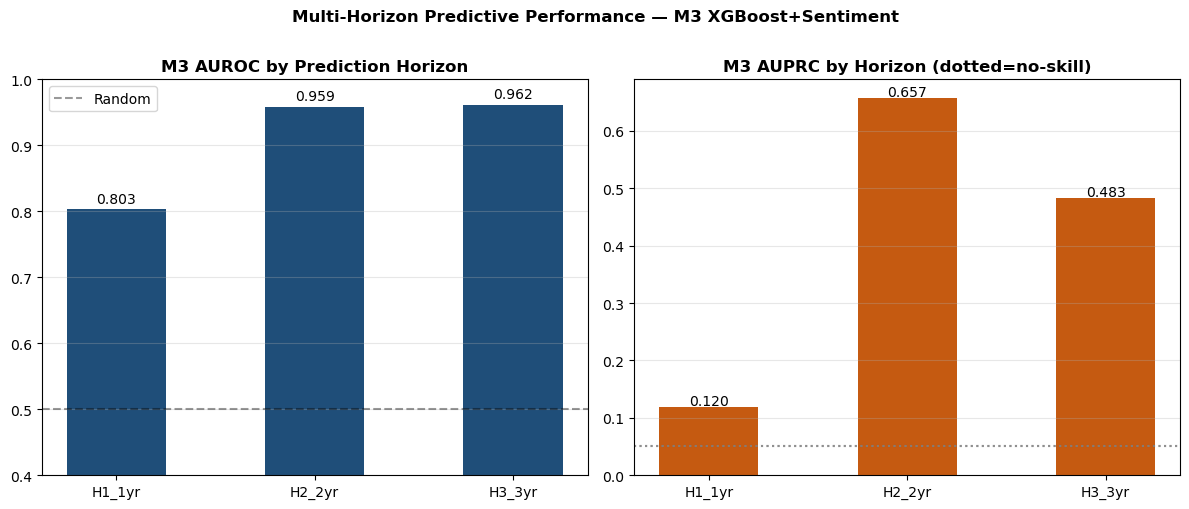

Saved fig_horizon_comparison.png


In [5]:
hz_path = IMP_DIR/'horizon_results.csv'
if hz_path.exists():
    hz = pd.read_csv(hz_path, index_col=0)
    print('Horizon results:'); print(hz.to_string())
    x = np.arange(len(hz))
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
    ax1.bar(x, hz['AUROC'], 0.5, color='#1F4E79')
    ax1.axhline(0.5,color='k',linestyle='--',alpha=0.4,label='Random')
    ax1.set_xticks(x); ax1.set_xticklabels(hz.index); ax1.set_ylim(0.4,1.0)
    ax1.set_title('M3 AUROC by Prediction Horizon',fontweight='bold')
    ax1.legend(); ax1.grid(True,alpha=0.3,axis='y')
    for i,v in enumerate(hz['AUROC']): ax1.text(i,v+0.01,f'{v:.3f}',ha='center',fontsize=10)
    ax2.bar(x, hz['AUPRC'], 0.5, color='#C55A11')
    for i,b in enumerate(hz['base_rate']): ax2.axhline(b,color='grey',linestyle=':',alpha=0.5)
    ax2.set_xticks(x); ax2.set_xticklabels(hz.index)
    ax2.set_title('M3 AUPRC by Horizon (dotted=no-skill)',fontweight='bold')
    ax2.grid(True,alpha=0.3,axis='y')
    for i,v in enumerate(hz['AUPRC']): ax2.text(i,v+0.003,f'{v:.3f}',ha='center',fontsize=10)
    plt.suptitle('Multi-Horizon Predictive Performance — M3 XGBoost+Sentiment',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_horizon_comparison.png',dpi=150,bbox_inches='tight')
    plt.show(); print(f'Saved fig_horizon_comparison.png')
else:
    print(f'No horizon_results.csv at {hz_path} — run NB05 first')

## Cell 4 — SHAP by Lag Depth + Sentiment Contribution Comparison

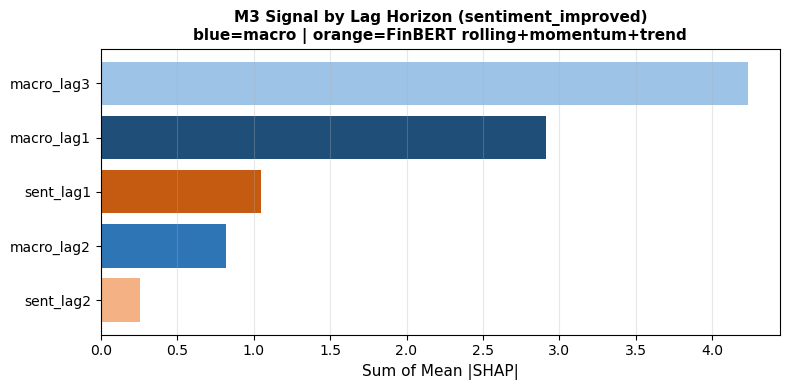

Lag importance:
macro_lag3    4.231299
macro_lag1    2.915166
sent_lag1     1.050890
macro_lag2    0.818394
sent_lag2     0.256186


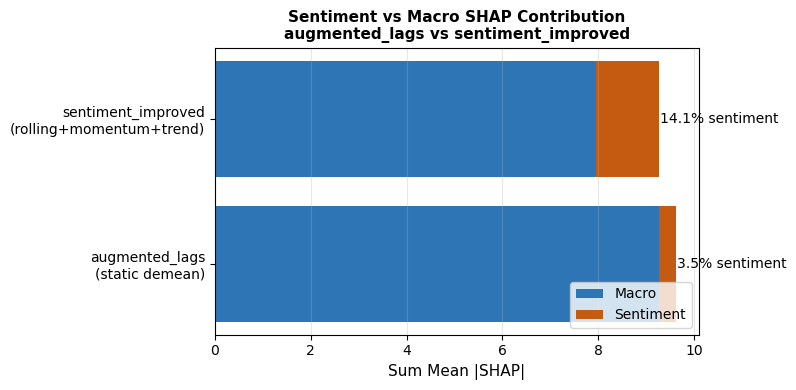

augmented_lags   : 3.5% sentiment
sentiment_improved: 14.1% sentiment
Change: +10.6 pp


In [21]:
shap_values = shap_df.values
mean_abs    = pd.Series(np.abs(shap_values).mean(axis=0), index=M3_FEATURES)

SENT_KEYS = ['P_pos','P_neg','P_neutral','net_sent','P_neg_change',
             'P_pos_change','net_sent_change','roll3','slope4']

def get_group(f):
    is_sent = any(s in f for s in SENT_KEYS)
    if '_lag1' in f and is_sent: return 'sent_lag1'
    if '_lag2' in f and is_sent: return 'sent_lag2'
    if '_lag1' in f: return 'macro_lag1'
    if '_lag2' in f: return 'macro_lag2'
    if '_lag3' in f: return 'macro_lag3'
    return 'other'

groups  = pd.Series({f: get_group(f) for f in M3_FEATURES})
lag_imp = mean_abs.groupby(groups).sum().reindex(
    ['macro_lag1','macro_lag2','macro_lag3','sent_lag1','sent_lag2','other']).dropna()
lag_imp = lag_imp.sort_values(ascending=False)

palette = {'macro_lag1':'#1F4E79','macro_lag2':'#2E75B6','macro_lag3':'#9DC3E6',
           'sent_lag1':'#C55A11','sent_lag2':'#F4B183','other':'#AAAAAA'}
fig,ax = plt.subplots(figsize=(8,4))
ax.barh(lag_imp.index[::-1],lag_imp.values[::-1],
        color=[palette.get(g,'#999') for g in lag_imp.index[::-1]])
ax.set_xlabel('Sum of Mean |SHAP|',fontsize=11)
ax.set_title('M3 Signal by Lag Horizon (sentiment_improved)\n'
             'blue=macro | orange=FinBERT rolling+momentum+trend',fontsize=11,fontweight='bold')
ax.grid(True,alpha=0.3,axis='x'); plt.tight_layout()
plt.savefig(FIG_DIR/'fig_shap_lag_depth.png',dpi=150,bbox_inches='tight')
plt.show(); print('Lag importance:'); print(lag_imp.to_string())

# Sentiment share comparison vs augmented_lags
aug_shap_p = AUG_DIR/'shap_values_m3.csv'
aug_feat_p = AUG_DIR/'M3_features.csv'
if aug_shap_p.exists() and aug_feat_p.exists():
    aug_shap  = pd.read_csv(aug_shap_p).values
    aug_feats = pd.read_csv(aug_feat_p,header=None)[0].tolist()
    aug_mean  = pd.Series(np.abs(aug_shap).mean(axis=0),index=aug_feats)
    def sent_share(ma,feats):
        sm=pd.Series([any(s in f for s in SENT_KEYS) for f in feats],index=feats)
        tot=ma.sum(); st=ma[sm].sum()
        return st,tot,100*st/tot if tot>0 else 0
    aug_s,aug_t,aug_pct = sent_share(aug_mean,aug_feats)
    imp_s,imp_t,imp_pct = sent_share(mean_abs,M3_FEATURES)
    fig,ax = plt.subplots(figsize=(8,4))
    vers=['augmented_lags\n(static demean)','sentiment_improved\n(rolling+momentum+trend)']
    mvals=[aug_t-aug_s,imp_t-imp_s]; svals=[aug_s,imp_s]; tots=[aug_t,imp_t]
    ax.barh(vers,mvals,color='#2E75B6',label='Macro')
    ax.barh(vers,svals,left=mvals,color='#C55A11',label='Sentiment')
    for i,(mv,sv,tot) in enumerate(zip(mvals,svals,tots)):
        ax.text(tot+0.02,i,f'{100*sv/tot:.1f}% sentiment',va='center',fontsize=10)
    ax.set_xlabel('Sum Mean |SHAP|',fontsize=11)
    ax.set_title('Sentiment vs Macro SHAP Contribution\naugmented_lags vs sentiment_improved',
                 fontsize=11,fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(True,alpha=0.3,axis='x'); plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_sentiment_contribution_comparison.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'augmented_lags   : {aug_pct:.1f}% sentiment')
    print(f'sentiment_improved: {imp_pct:.1f}% sentiment')
    print(f'Change: {imp_pct-aug_pct:+.1f} pp')

## Cell 5 — Top-20 SHAP and Temporal

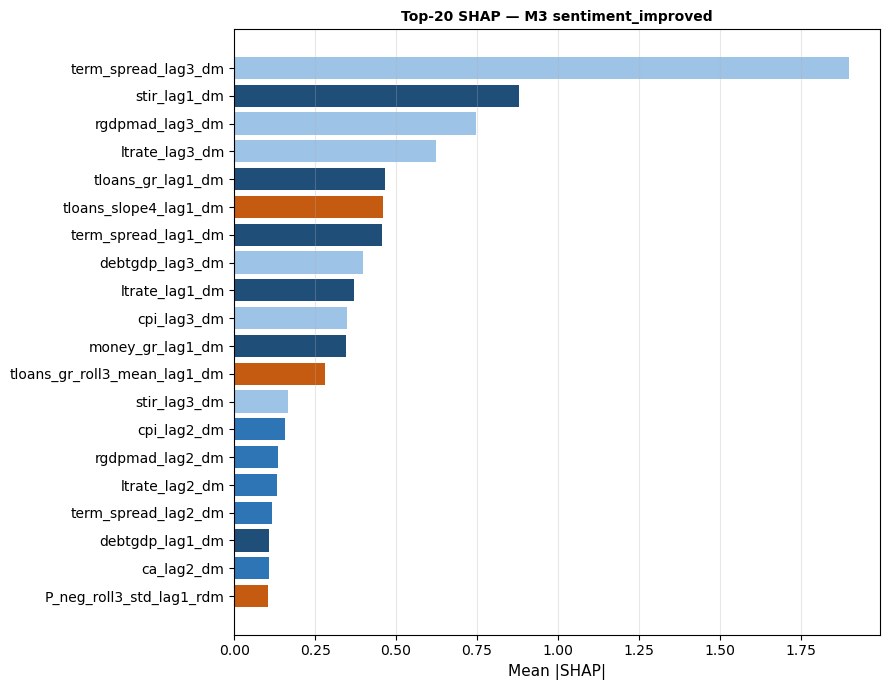

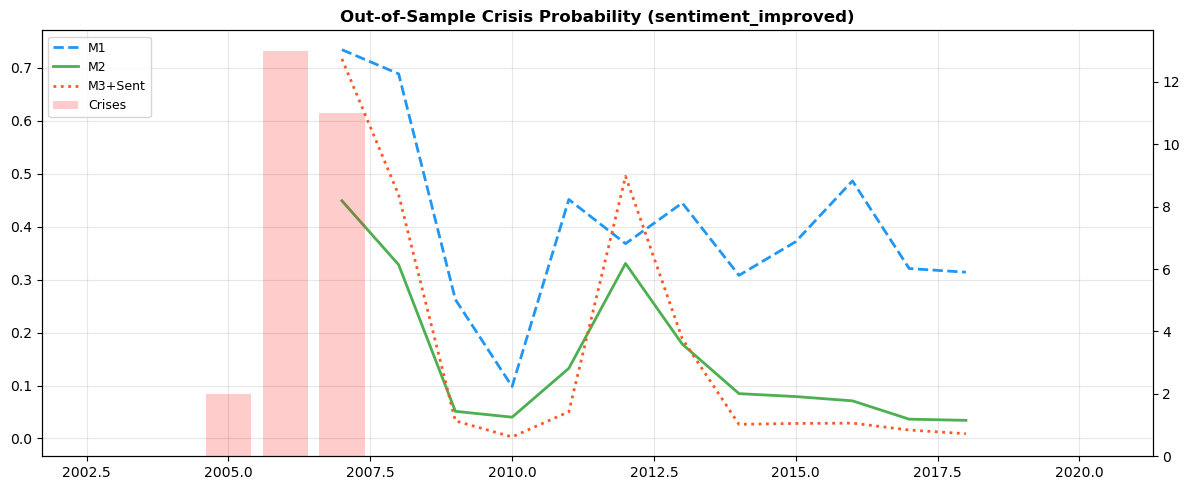

In [23]:
# Top-20 SHAP
mean_abs_sorted = mean_abs.sort_values(ascending=True).tail(20)
def fc(f): return ('#C55A11' if any(s in f for s in SENT_KEYS) else
                   ('#9DC3E6' if '_lag3' in f else ('#2E75B6' if '_lag2' in f else '#1F4E79')))
fig,ax = plt.subplots(figsize=(9,7))
ax.barh(mean_abs_sorted.index,mean_abs_sorted.values,
        color=[fc(f) for f in mean_abs_sorted.index])
ax.set_xlabel('Mean |SHAP|',fontsize=11)
ax.set_title('Top-20 SHAP — M3 sentiment_improved',fontsize=10,fontweight='bold')
ax.grid(True,alpha=0.3,axis='x'); plt.tight_layout()
plt.savefig(FIG_DIR/'fig_shap_top20.png',dpi=150,bbox_inches='tight'); plt.show()

# Temporal
yearly=oos_df.groupby('year').agg(
    prob_m1=('prob_m1','mean'),prob_m2=('prob_m2','mean'),
    prob_m3=('prob_m3','mean'),actual=(TARGET,'sum')).reset_index()
fig,ax1=plt.subplots(figsize=(12,5)); ax2=ax1.twinx()
ax1.plot(yearly['year'],yearly['prob_m1'],color='#2196F3',lw=2,label='M1',ls='--')
ax1.plot(yearly['year'],yearly['prob_m2'],color='#4CAF50',lw=2,label='M2')
ax1.plot(yearly['year'],yearly['prob_m3'],color='#FF5722',lw=2,label='M3+Sent',ls=':')
ax2.bar(yearly['year'],yearly['actual'],alpha=0.2,color='red',label='Crises')
l1,lb1=ax1.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
ax1.legend(l1+l2,lb1+lb2,loc='upper left',fontsize=9)
ax1.set_title('Out-of-Sample Crisis Probability (sentiment_improved)',fontsize=12,fontweight='bold')
ax1.grid(True,alpha=0.3); plt.tight_layout()
plt.savefig(FIG_DIR/'fig_temporal_probs.png',dpi=150,bbox_inches='tight'); plt.show()

## Cell 6 — Output Inventory

In [25]:
# Country-level error audit using M2 predictions (primary macro-only model)
# Threshold: top quantile of predicted probabilities

oos_full = oos_df.copy()
oos_full['year'] = oos_full['year'].astype(int)

# Use M2 as primary model for audit
threshold = np.nanpercentile(oos_full['prob_m2'].dropna(), 80)  # top 20%
oos_full['pred_m2'] = (oos_full['prob_m2'] >= threshold).astype(int)

TARGET_COL = next(c for c in oos_full.columns if 'target' in c.lower())

# Confusion by country
country_audit = []
for ctry in sorted(oos_full['iso'].unique()):
    sub = oos_full[oos_full['iso']==ctry].dropna(subset=['prob_m2'])
    if len(sub) == 0: continue
    tp = int(((sub[TARGET_COL]==1) & (sub['pred_m2']==1)).sum())
    fp = int(((sub[TARGET_COL]==0) & (sub['pred_m2']==1)).sum())
    fn = int(((sub[TARGET_COL]==1) & (sub['pred_m2']==0)).sum())
    tn = int(((sub[TARGET_COL]==0) & (sub['pred_m2']==0)).sum())
    n_crisis = int(sub[TARGET_COL].sum())
    country_audit.append({'country':ctry,'TP':tp,'FP':fp,'FN':fn,'TN':tn,
                          'n_crisis':n_crisis,'n_obs':len(sub)})

audit_df = pd.DataFrame(country_audit)
audit_df['precision'] = audit_df['TP'] / (audit_df['TP'] + audit_df['FP']).replace(0, np.nan)
audit_df['recall']    = audit_df['TP'] / (audit_df['TP'] + audit_df['FN']).replace(0, np.nan)

print('Country-Level Error Audit — M2 (threshold = top 20% predicted prob)')
print('='*70)
print(audit_df[['country','n_crisis','TP','FP','FN','TN']].to_string(index=False))
print()
print('Countries with false alarms (FP > 0):',
      audit_df[audit_df['FP']>0]['country'].tolist())
print('Countries with missed crises (FN > 0):',
      audit_df[audit_df['FN']>0]['country'].tolist())

audit_df.to_csv(IMP_DIR/'country_error_audit.csv', index=False)
print(f'Saved country_error_audit.csv')

Country-Level Error Audit — M2 (threshold = top 20% predicted prob)
country  n_crisis  TP  FP  FN  TN
    AUS         0   0   1   0  11
    BEL         1   1   2   0   9
    CAN         0   0   4   0   8
    CHE         1   0   4   1   7
    DEU         1   1   3   0   8
    DNK         1   1   3   0   8
    ESP         1   1   1   0   9
    FIN         0   0   0   0  12
    FRA         1   1   2   0   9
    GBR         0   0   1   0  11
    IRL         1   1   1   0  10
    ITA         1   1   1   0  10
    JPN         0   0   0   0  12
    NLD         1   1   1   0  10
    NOR         0   0   3   0   9
    PRT         1   1   1   0  10
    SWE         1   1   3   0   8
    USA         0   0   2   0  10

Countries with false alarms (FP > 0): ['AUS', 'BEL', 'CAN', 'CHE', 'DEU', 'DNK', 'ESP', 'FRA', 'GBR', 'IRL', 'ITA', 'NLD', 'NOR', 'PRT', 'SWE', 'USA']
Countries with missed crises (FN > 0): ['CHE']
Saved country_error_audit.csv


## Cell — Country-Level Error Audit

Identifies which countries the model systematically misclassifies.
Differentiates false alarms (FP) from missed crises (FN) by country.
This goes in the dissertation Appendix or Results section.


## Cell — Threshold Curve: Precision and Recall vs Decision Threshold

Shows how precision and recall change at every possible classification threshold
for M2 and M3. The optimal threshold is where the F1 score peaks, or where the
gap between precision and recall is acceptable for the policy use case.

This is important for macroprudential applications where the regulator must
choose a specific alert threshold.

M2: Random Forest: optimal threshold=0.574  Precision=0.636  Recall=0.636  F1=0.636
M3: XGBoost+Sent: optimal threshold=0.933  Precision=0.714  Recall=0.909  F1=0.800


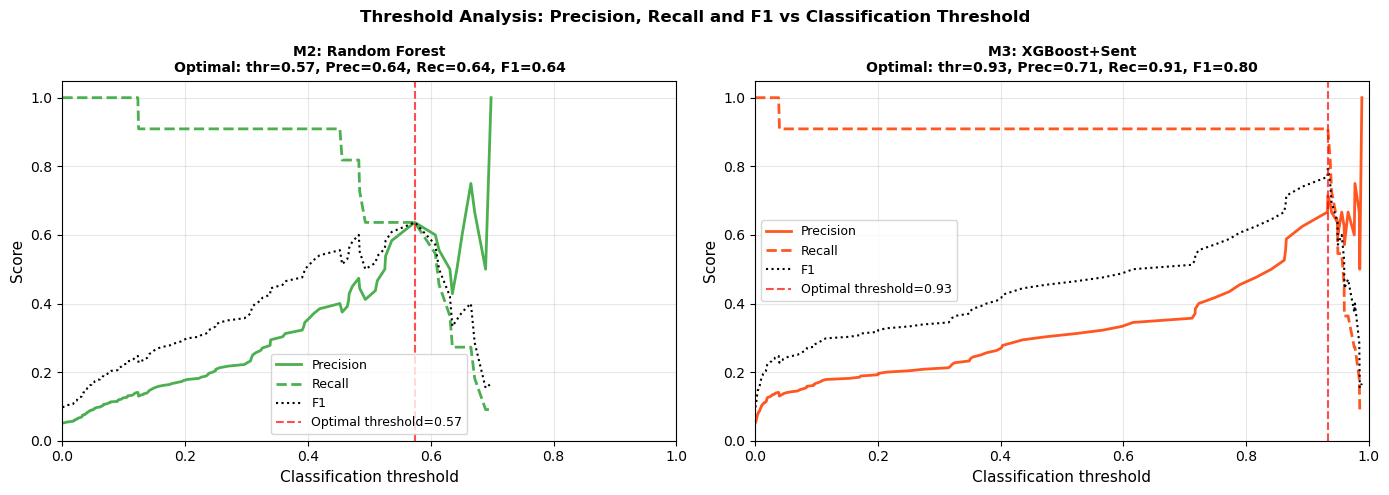

Saved threshold_curve.png

NOTE: Optimal threshold maximises F1. Macroprudential use may prefer
lower threshold (higher recall) to avoid missing crises, accepting
more false alarms — the policy loss function governs this choice.


In [7]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, y_t, y_p, color) in zip(axes, [
    ('M2: Random Forest', y_true, oos_df['prob_m2'].values, '#4CAF50'),
    ('M3: XGBoost+Sent',  y_true, oos_df['prob_m3'].values, '#FF5722'),
]):
    mask = ~np.isnan(y_p)
    yt, yp = y_t[mask], y_p[mask]
    precision, recall, thresholds = precision_recall_curve(yt, yp)

    # F1 at each threshold
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx  = np.argmax(f1)
    best_thr  = thresholds[best_idx]
    best_f1   = f1[best_idx]
    best_prec = precision[best_idx]
    best_rec  = recall[best_idx]

    ax.plot(thresholds, precision[:-1], color=color, lw=2, label='Precision')
    ax.plot(thresholds, recall[:-1],    color=color, lw=2, label='Recall', linestyle='--')
    ax.plot(thresholds, f1,             color='black', lw=1.5, label='F1', linestyle=':')
    ax.axvline(best_thr, color='red', linestyle='--', alpha=0.7,
               label=f'Optimal threshold={best_thr:.2f}')
    ax.set_xlabel('Classification threshold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{model_name}\nOptimal: thr={best_thr:.2f}, Prec={best_prec:.2f}, Rec={best_rec:.2f}, F1={best_f1:.2f}',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    print(f'{model_name}: optimal threshold={best_thr:.3f}  Precision={best_prec:.3f}  Recall={best_rec:.3f}  F1={best_f1:.3f}')

plt.suptitle('Threshold Analysis: Precision, Recall and F1 vs Classification Threshold',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved threshold_curve.png')
print()
print('NOTE: Optimal threshold maximises F1. Macroprudential use may prefer')
print('lower threshold (higher recall) to avoid missing crises, accepting')
print('more false alarms — the policy loss function governs this choice.')

### Calibration Diagnostics — Reliability Diagrams and ECE

In [ ]:
# ── Calibration Diagnostics ─────────────────────────────────────────────────
# Reliability diagrams (calibration curves) and Expected Calibration Error
# for M2 (Random Forest) and M3 (XGBoost+Sentiment).
#
# A well-calibrated model has points on the diagonal: predicted prob = observed freq.
# Curves above diagonal → overconfident (probabilities too high).
# Curves below diagonal → underconfident (probabilities too low).
#
# NOTE: Calibration is assessed on pooled OOS predictions. With only 26 crisis
# events, individual bins are noisy — treat patterns directionally.
# Post-hoc recalibration (Platt/isotonic) applied here would be circular since
# we are fitting and evaluating on the same OOS set. The correct fix is to apply
# CalibratedClassifierCV in NB05 during the expanding-window training loop.

from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Weighted ECE across equal-width probability bins."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()   # observed frequency in bin
        bin_conf = y_prob[mask].mean()    # mean predicted probability
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return ece

models_calib = [
    ('M2: Random Forest',  oos_df['prob_m2'].values, '#4CAF50'),
    ('M3: XGBoost+Sent',   oos_df['prob_m3'].values, '#FF5722'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, y_prob, color) in zip(axes, models_calib):
    mask = ~np.isnan(y_prob)
    yt, yp = y_true[mask], y_prob[mask]

    # sklearn calibration_curve: n_bins kept small given few crisis events
    frac_pos, mean_pred = calibration_curve(yt, yp, n_bins=8, strategy='uniform')
    ece = expected_calibration_error(yt, yp, n_bins=10)

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2, ms=7, label=name)
    ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.15, color=color)

    # Rug: distribution of predicted probabilities
    ax2 = ax.twinx()
    ax2.hist(yp, bins=30, color=color, alpha=0.15, density=True)
    ax2.set_ylabel('Density of predicted probs', fontsize=9, color='grey')
    ax2.tick_params(axis='y', labelcolor='grey', labelsize=8)

    ax.set_xlabel('Mean predicted probability', fontsize=11)
    ax.set_ylabel('Observed crisis frequency', fontsize=11)
    ax.set_title(f'{name}\nECE = {ece:.4f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    print(f'{name}: ECE = {ece:.4f} | prob range [{yp.min():.3f}, {yp.max():.3f}] '
          f'| median = {np.median(yp):.3f}')

plt.suptitle('Calibration Reliability Diagrams — M2 vs M3',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_calibration_curves.png')
print()
print('CALIBRATION INTERPRETATION:')
print('  M3 (XGBoost): Raw XGBoost probabilities are known to be poorly calibrated.')
print('  A high optimal threshold (~0.93) is a symptom — the model compresses')
print('  predicted probabilities toward zero, so even true positives receive low scores.')
print('  This does not affect rank-order metrics (AUROC) but distorts threshold-based')
print('  metrics (F1, Precision, Recall) and the Alessi-Detken usefulness score.')
print('  Platt scaling or isotonic regression in NB05 would address this.')
print('  M2 (Random Forest): RF probabilities are generally better calibrated;')
print('  the more central optimal threshold (~0.57) is consistent with this.')


## Cell — Bootstrap Difference-in-AUPRC: M3 vs M2

Tests whether the AUPRC advantage of M3 over M2 is statistically distinguishable
from zero by bootstrapping the difference.

With 26 crisis events, confidence intervals will be wide — the honest result.
If the CI includes zero, the advantage is directional but not statistically confirmed.

In [11]:
from sklearn.utils import resample
from sklearn.metrics import average_precision_score
import numpy as np

print('=== BOOTSTRAP DIFFERENCE-IN-AUPRC: M3 vs M2 ===')
print()

mask_m2 = ~np.isnan(oos_df['prob_m2'].values)
mask_m3 = ~np.isnan(oos_df['prob_m3'].values)
mask    = mask_m2 & mask_m3

yt_d  = y_true[mask]
yp_m2 = oos_df['prob_m2'].values[mask]
yp_m3 = oos_df['prob_m3'].values[mask]

N_BOOT = 2000
diffs  = []
rng    = np.random.RandomState(42)

for _ in range(N_BOOT):
    idx = resample(np.arange(len(yt_d)), random_state=rng)
    yt_b, y2_b, y3_b = yt_d[idx], yp_m2[idx], yp_m3[idx]
    if yt_b.sum() == 0: continue
    try:
        d = average_precision_score(yt_b, y3_b) - average_precision_score(yt_b, y2_b)
        diffs.append(d)
    except: pass

ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
point_diff   = average_precision_score(yt_d, yp_m3) - average_precision_score(yt_d, yp_m2)

print(f'Point estimate: M3 AUPRC - M2 AUPRC = {point_diff:+.4f}')
print(f'Bootstrap 95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]  ({N_BOOT} resamples)')
print()
if ci_lo > 0:
    verdict = 'CI entirely positive — M3 advantage statistically distinguishable from zero'
elif ci_hi < 0:
    verdict = 'CI entirely negative — M2 advantage statistically distinguishable from zero'
else:
    verdict = 'CI includes zero — advantage is directional but not statistically confirmed'
print(f'Verdict: {verdict}')
print()
print('HONEST INTERPRETATION:')
print('With 26 crisis events, bootstrap CIs will typically span zero.')
print('This is not a flaw — it is the correct reflection of statistical power.')
print('Report the point estimate and CI together; do not claim significance')
print('unless the CI is clearly above zero.')

# Save result
pd.DataFrame({'metric':['M3_minus_M2_AUPRC','CI_lo','CI_hi'],
              'value':[point_diff,ci_lo,ci_hi]}).to_csv(IMP_DIR/'auprc_difference_ci.csv',index=False)
print('Saved auprc_difference_ci.csv')

=== BOOTSTRAP DIFFERENCE-IN-AUPRC: M3 vs M2 ===

Point estimate: M3 AUPRC - M2 AUPRC = +0.0962
Bootstrap 95% CI: [-0.1646, +0.3575]  (2000 resamples)

Verdict: CI includes zero — advantage is directional but not statistically confirmed

HONEST INTERPRETATION:
With 26 crisis events, bootstrap CIs will typically span zero.
This is not a flaw — it is the correct reflection of statistical power.
Report the point estimate and CI together; do not claim significance
unless the CI is clearly above zero.
Saved auprc_difference_ci.csv


In [12]:
print('='*65); print(' NB06 COMPLETE'); print('='*65)
print(f'Target: {TARGET} | Events: {int(y_true.sum())}')
print()
print('Figures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name:50s}  {f.stat().st_size//1024:4d} KB')
print('CSVs:')
for f in sorted(IMP_DIR.glob('*.csv')):
    print(f'  {f.name:50s}  {f.stat().st_size//1024:4d} KB')

 NB06 COMPLETE
Target: target_h2 | Events: 26

Figures:
  calibration_plot.png                                  87 KB
  fig_horizon_comparison.png                            60 KB
  fig_sentiment_contribution_comparison.png             51 KB
  fig_shap_lag_depth.png                                41 KB
  fig_shap_top20.png                                    91 KB
  fig_temporal_probs.png                                97 KB
  granger_causality.png                                 86 KB
  roc_pr_curves.png                                    106 KB
  shap_by_lag_depth.png                                 41 KB
  shap_fold_stability.png                               79 KB
  shap_summary_m3.png                                  231 KB
  threshold_curve.png                                  142 KB
CSVs:
  auprc_difference_ci.csv                                0 KB
  calibration_table.csv                                  0 KB
  country_error_audit.csv                                0 KB
  df_mod